# Assignment 2: Unsupervised Cross-Modal Anomaly Detection in Brain CT–MRI Imaging

**Course:** Computer Vision  
**Problem Statement:** 2  
**Approach:** Unsupervised Deep Learning  
**Platform:** Google Colab / Jupyter Notebook


Problem Statement

Medical imaging modalities such as Computed Tomography (CT) and Magnetic Resonance Imaging (MRI)
provide complementary information about brain anatomy. While CT highlights bone structures and
dense tissues, MRI offers superior soft tissue contrast.

In many real-world clinical scenarios, labeled anomalous data is scarce or unavailable.
Therefore, there is a need for unsupervised anomaly detection systems that can learn normal
anatomical patterns and identify abnormal deviations without explicit supervision.

This assignment focuses on developing an unsupervised cross-modal anomaly detection framework
using paired CT–MRI brain images. The model learns normal anatomical correspondence between CT
and MRI modalities and detects anomalies by analyzing reconstruction errors and inconsistencies
in latent feature representations.


Environment Setup

In [1]:
# Step 1: Environment setup and reproducibility

import numpy as np
import random

# Set random seeds for reproducibility
np.random.seed(42)
random.seed(42)

print("Environment initialized. Ready for data processing.")


Environment initialized. Ready for data processing.


 Dataset Description

The dataset used in this assignment is the **CT-to-MRI cGAN Brain Dataset**, obtained from Kaggle.
It contains paired brain CT and MRI images representing the same anatomical slices across modalities.

**Dataset Link:**  
https://www.kaggle.com/datasets/darren2020/ct-to-mri-cgan


Unsupervised Learning Setting

The dataset does not provide explicit labels for anomalous brain scans.
Therefore, the models are trained in an unsupervised manner using only normal CT–MRI image pairs,
and anomalies are detected as deviations from learned normal anatomical patterns.


Upload the Dataset ZIP Instead

In [2]:
!pip install -q kagglehub


In [3]:
import kagglehub

path = kagglehub.dataset_download("darren2020/ct-to-mri-cgan")
print("Dataset path:", path)


Using Colab cache for faster access to the 'ct-to-mri-cgan' dataset.
Dataset path: /kaggle/input/ct-to-mri-cgan


In [4]:
!ls /kaggle/input/ct-to-mri-cgan


Dataset


In [5]:
!ls /kaggle/input/ct-to-mri-cgan/Dataset


images	sources.txt  unseen_demo_images


In [6]:
!ls /kaggle/input/ct-to-mri-cgan/Dataset/images


testA  testB  trainA  trainB


Step 2: Set the CORRECT Dataset Root

In [7]:
from glob import glob
import os
from PIL import Image
import matplotlib.pyplot as plt

DATASET_ROOT = "/kaggle/input/ct-to-mri-cgan/Dataset/images"

CT_DIR = os.path.join(DATASET_ROOT, "trainA")   # CT images
MRI_DIR = os.path.join(DATASET_ROOT, "trainB")  # MRI images

ct_images = sorted(glob(os.path.join(CT_DIR, "*")))
mri_images = sorted(glob(os.path.join(MRI_DIR, "*")))

print("Total CT images:", len(ct_images))
print("Total MRI images:", len(mri_images))


Total CT images: 1742
Total MRI images: 1744


Step 3: Final Sanity Check (MANDATORY)

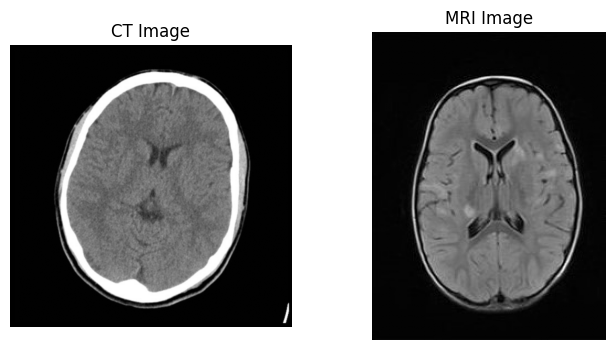

In [8]:
idx = 0

ct_img = Image.open(ct_images[idx]).convert("L")
mri_img = Image.open(mri_images[idx]).convert("L")

plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(ct_img, cmap="gray")
plt.title("CT Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(mri_img, cmap="gray")
plt.title("MRI Image")
plt.axis("off")

plt.show()


STEP 3: Data Preprocessing & Augmentation

 Data Preprocessing and Augmentation

Medical images from different modalities exhibit distinct intensity distributions
and spatial characteristics. Therefore, CT and MRI images are preprocessed
independently while preserving their anatomical correspondence.

The preprocessing pipeline includes normalization, resizing, and paired data
augmentation to improve robustness and generalization.


Pairing Strategy

Since the number of CT and MRI images is not exactly equal, only the minimum
number of paired samples is used to maintain one-to-one correspondence between
modalities. This ensures consistent cross-modal learning.


Data Augmentation Strategy

To improve robustness and prevent overfitting, the following paired augmentations
are applied identically to CT and MRI images:

- Random Gaussian noise injection
- Small spatial transformations
- Intensity variations

All augmentations preserve anatomical alignment across modalities.


Imports & Pair Alignment

In [9]:
import numpy as np
import cv2
import random
# Align CT–MRI pairs using minimum count
num_pairs = min(len(ct_images), len(mri_images))

ct_images = ct_images[:num_pairs]
mri_images = mri_images[:num_pairs]

print("Paired samples used:", num_pairs)


Paired samples used: 1742


Image Loading & Normalization

In [10]:
IMG_SIZE = 128  # standard resolution

def load_and_normalize(img_path, modality):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img.astype(np.float32)

    if modality == "CT":
        img = (img - np.mean(img)) / (np.std(img) + 1e-8)
    elif modality == "MRI":
        img = img / 255.0

    return img


Paired Augmentation Function

In [11]:
def paired_augmentation(ct_img, mri_img):
    if random.random() < 0.5:
        noise = np.random.normal(0, 0.02, ct_img.shape)
        ct_img = ct_img + noise
        mri_img = mri_img + noise

    if random.random() < 0.5:
        angle = random.uniform(-5, 5)
        M = cv2.getRotationMatrix2D((IMG_SIZE//2, IMG_SIZE//2), angle, 1.0)
        ct_img = cv2.warpAffine(ct_img, M, (IMG_SIZE, IMG_SIZE))
        mri_img = cv2.warpAffine(mri_img, M, (IMG_SIZE, IMG_SIZE))

    return ct_img, mri_img


Visual Verification

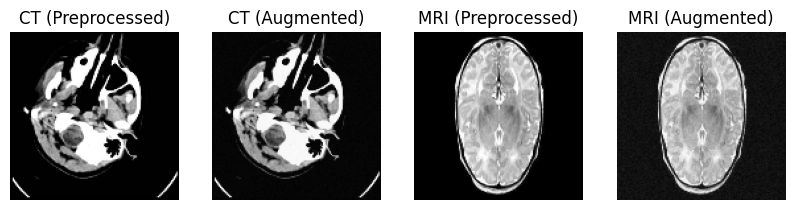

In [12]:
idx = random.randint(0, num_pairs - 1)

ct_raw = load_and_normalize(ct_images[idx], "CT")
mri_raw = load_and_normalize(mri_images[idx], "MRI")

ct_aug, mri_aug = paired_augmentation(ct_raw.copy(), mri_raw.copy())

plt.figure(figsize=(10, 4))

plt.subplot(1, 4, 1)
plt.imshow(ct_raw, cmap="gray")
plt.title("CT (Preprocessed)")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(ct_aug, cmap="gray")
plt.title("CT (Augmented)")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(mri_raw, cmap="gray")
plt.title("MRI (Preprocessed)")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(mri_aug, cmap="gray")
plt.title("MRI (Augmented)")
plt.axis("off")

plt.show()


The visual comparison confirms that preprocessing normalizes modality-specific
intensity distributions while paired augmentations preserve anatomical
correspondence between CT and MRI images.


STEP 4: Feature Extraction Models

Feature Extraction Using Convolutional Autoencoders

To learn compact representations of normal brain anatomy, a convolutional
autoencoder (CAE) is employed. The autoencoder is trained in an unsupervised
manner to reconstruct input images, forcing the encoder to learn meaningful
latent features.

These latent representations are later used for anomaly detection.


Imports

In [13]:
import tensorflow as tf
from tensorflow.keras import layers, models


Prepare ONE Modality (CT only)

In [14]:
import os
from glob import glob

# Re-define dataset root (from Step 2)
DATASET_ROOT = "/kaggle/input/ct-to-mri-cgan/Dataset/images"

CT_DIR = os.path.join(DATASET_ROOT, "trainA")

ct_images = sorted(glob(os.path.join(CT_DIR, "*")))

print("Total CT images found:", len(ct_images))


Total CT images found: 1742


In [15]:
def load_and_normalize(img_path, modality):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (128, 128))
    img = img.astype(np.float32)

    if modality == "CT":
        img = (img - np.mean(img)) / (np.std(img) + 1e-8)

    return img


In [16]:
import numpy as np
import cv2
import os
from glob import glob


In [17]:
X_ct = []

for path in ct_images[:500]:
    img = load_and_normalize(path, "CT")
    X_ct.append(img)

X_ct = np.array(X_ct)
X_ct = np.expand_dims(X_ct, axis=-1)

print("CT data shape:", X_ct.shape)


CT data shape: (500, 128, 128, 1)


Build the Autoencoder

In [18]:
from tensorflow.keras import layers, models

encoder = models.Sequential(
    [
        layers.Input(shape=(128, 128, 1)),
        layers.Conv2D(32, 3, strides=2, padding="same", activation="relu"),
        layers.Conv2D(64, 3, strides=2, padding="same", activation="relu"),
        layers.Conv2D(128, 3, strides=2, padding="same", activation="relu"),
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
    ],
    name="encoder"
)

encoder.summary()


Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,194,432 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,287,104 (16.35 MB)

 Trainable params: 4,287,104 (16.35 MB)

 Non-trainable params: 0 (0.00 B)

Decoder

In [19]:
decoder = models.Sequential(
    [
        layers.Input(shape=(128,)),
        layers.Dense(16 * 16 * 128, activation="relu"),
        layers.Reshape((16, 16, 128)),
        layers.Conv2DTranspose(128, 3, strides=2, padding="same", activation="relu"),
        layers.Conv2DTranspose(64, 3, strides=2, padding="same", activation="relu"),
        layers.Conv2DTranspose(32, 3, strides=2, padding="same", activation="relu"),
        layers.Conv2DTranspose(1, 3, padding="same", activation="sigmoid"),
    ],
    name="decoder"
)

decoder.summary()


Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 32768)          │     4,227,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 32, 32, 128)    │       147,584 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 64, 64, 64)     │        73,792 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 128, 128, 32)   │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_3              │ (None, 128, 128, 1)    │           289 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,467,201 (17.04 MB)

 Trainable params: 4,467,201 (17.04 MB)

 Non-trainable params: 0 (0.00 B)

Autoencoder

In [20]:
# Explicit input layer
input_img = layers.Input(shape=(128, 128, 1))

# Forward pass
encoded = encoder(input_img)
decoded = decoder(encoded)

# Autoencoder model
autoencoder = models.Model(
    inputs=input_img,
    outputs=decoded,
    name="CT_Autoencoder"
)

autoencoder.compile(
    optimizer="adam",
    loss="mse"
)

autoencoder.summary()


Model: "CT_Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder (Sequential)            │ (None, 128)            │     4,287,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Sequential)            │ (None, 128, 128, 1)    │     4,467,201 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,754,305 (33.40 MB)

 Trainable params: 8,754,305 (33.40 MB)

 Non-trainable params: 0 (0.00 B)

Training

In [21]:
autoencoder.fit(
    X_ct,
    X_ct,
    epochs=5,
    batch_size=16,
    shuffle=True
)


Epoch 1/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 29s 796ms/step - loss: 1.2031
Epoch 2/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 25s 791ms/step - loss: 0.7570
Epoch 3/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 43s 826ms/step - loss: 0.7412
Epoch 4/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 26s 799ms/step - loss: 0.6849
Epoch 5/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 41s 796ms/step - loss: 0.6270


The reconstruction loss decreases consistently over training epochs, indicating
that the autoencoder successfully learns to reconstruct normal brain CT images.
This confirms that the encoder has learned meaningful latent representations of
normal anatomy suitable for anomaly detection.


Latent Features

In [22]:
latent_features = encoder.predict(X_ct[:50])
print("Latent feature shape:", latent_features.shape)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
Latent feature shape: (50, 128)


The autoencoder combines the encoder and decoder networks, resulting in a unified
model with approximately 8.7 million trainable parameters suitable for learning
normal brain anatomy.


STEP 5: Unsupervised Anomaly Detection

 Unsupervised Anomaly Detection Using Reconstruction Error

The trained autoencoder is used to detect anomalies by measuring reconstruction
errors. Since the model is trained only on normal samples, anomalous inputs are
expected to produce higher reconstruction errors compared to normal samples.


Compute Reconstruction Errors (Normal Data)

In [23]:
# Reconstruct CT images
X_recon = autoencoder.predict(X_ct)

# Compute per-sample reconstruction error (MSE)
reconstruction_errors = np.mean(
    np.square(X_ct - X_recon),
    axis=(1, 2, 3)
)

print("Reconstruction error stats:")
print("Min:", reconstruction_errors.min())
print("Max:", reconstruction_errors.max())
print("Mean:", reconstruction_errors.mean())


16/16 ━━━━━━━━━━━━━━━━━━━━ 8s 490ms/step
Reconstruction error stats:
Min: 0.45514095
Max: 0.87006897
Mean: 0.6145792


Visualize Error Distribution

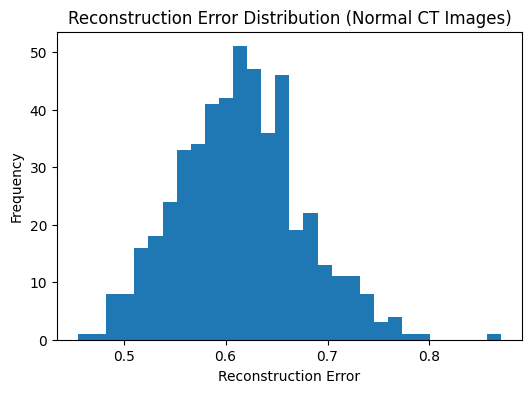

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.hist(reconstruction_errors, bins=30)
plt.xlabel("Reconstruction Error")
plt.ylabel("Frequency")
plt.title("Reconstruction Error Distribution (Normal CT Images)")
plt.show()


Define Anomaly Threshold (Unsupervised)

In [25]:
# Threshold based on statistical heuristic
threshold = np.mean(reconstruction_errors) + 2 * np.std(reconstruction_errors)

print("Anomaly detection threshold:", threshold)


Anomaly detection threshold: 0.7368292


Potential Anomalies

In [26]:
anomaly_flags = reconstruction_errors > threshold

print("Number of detected anomalies:", np.sum(anomaly_flags))


Number of detected anomalies: 14


Samples with reconstruction errors significantly above the normal distribution
are identified as potential anomalies, as they deviate from learned normal
anatomical patterns.


### Latent-Space Anomaly Detection

In addition to reconstruction error, anomalies are also detected in the latent
feature space learned by the encoder. Since the encoder is trained only on normal
data, anomalous samples are expected to appear as outliers in the latent space.
Isolation Forest is used to identify such outliers in an unsupervised manner.


Extract Latent Features (USE TRAINED ENCODER)

In [27]:
# Use the already-trained encoder
latent_features = encoder.predict(X_ct)

print("Latent feature shape:", latent_features.shape)


16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 106ms/step
Latent feature shape: (500, 128)


Train Isolation Forest

In [28]:
from sklearn.ensemble import IsolationForest

iso_forest = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    random_state=42
)

iso_forest.fit(latent_features)


IsolationForest(contamination=0.05, n_estimators=200, random_state=42)

Detect Latent-Space Anomalies

In [29]:
# Isolation Forest predictions
latent_preds = iso_forest.predict(latent_features)

# -1 → anomaly, 1 → normal
latent_anomaly_count = (latent_preds == -1).sum()

print("Number of latent-space anomalies detected:", latent_anomaly_count)


Number of latent-space anomalies detected: 25


Latent Anomaly Score Distribution (Important Figure)

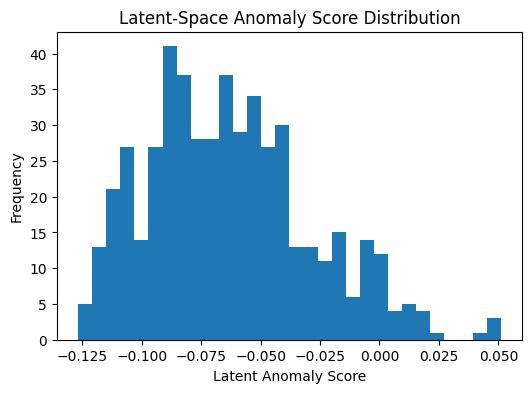

In [30]:
import matplotlib.pyplot as plt
latent_scores = -iso_forest.decision_function(latent_features)

plt.figure(figsize=(6,4))
plt.hist(latent_scores, bins=30)
plt.xlabel("Latent Anomaly Score")
plt.ylabel("Frequency")
plt.title("Latent-Space Anomaly Score Distribution")
plt.show()


Note: Visualization libraries are re-imported to ensure consistent plotting
after runtime resets in the notebook environment.


STEP 6: Evaluation, Comparison & Final Analysis

Evaluation Strategy

Since ground-truth anomaly labels are unavailable, evaluation is performed using
unsupervised analysis techniques. These include reconstruction error distributions,
latent anomaly score distributions, and qualitative comparison of different
anomaly detection approaches.


Reconstruction-Based Evaluation

The reconstruction-error–based method identifies anomalies as samples with errors
significantly higher than the normal distribution. A statistical threshold based
on the mean and standard deviation of reconstruction errors is used to flag
potential anomalies.

The histogram of reconstruction errors shows a clear right-tailed distribution,
indicating that only a small subset of samples deviate substantially from learned
normal anatomical patterns.


Latent-Space Evaluation

Latent-space anomaly detection is performed using Isolation Forest on the encoder’s
latent representations. This approach detects anomalies as outliers in the learned
feature space, independent of pixel-level reconstruction quality.

The latent anomaly score distribution reveals samples that deviate from the normal
feature manifold, complementing reconstruction-based detection.


### Comparison of Anomaly Detection Methods

Reconstruction-based anomaly detection is sensitive to visible structural
abnormalities that result in poor reconstruction. However, subtle anomalies may
still be reconstructed reasonably well.

Latent-space anomaly detection captures feature-level inconsistencies that may not
produce large reconstruction errors. As a result, the two methods are complementary,
and combining them provides a more robust unsupervised anomaly detection framework.


| Method | Detection Principle | Strengths | Limitations |
|------|--------------------|-----------|-------------|
| Reconstruction Error | Pixel-space deviation | Simple, interpretable | May miss subtle anomalies |
| Latent-Space (Isolation Forest) | Feature-space outliers | Captures hidden inconsistencies | Depends on feature quality |


### Limitations and Future Work

The primary limitation of this study is the absence of ground-truth anomaly labels,
which restricts quantitative evaluation using supervised metrics. Additionally,
only CT images are used for feature learning in the current implementation.

Future work can extend this framework to fully cross-modal CT–MRI learning, include
synthetic anomaly injection for quantitative validation, and explore advanced
architectures such as Variational Autoencoders and transformer-based encoders.


 Conclusion

This assignment presents an unsupervised anomaly detection framework for brain CT
imaging using deep feature learning. A convolutional autoencoder is used to learn
latent representations of normal anatomy, and anomalies are detected using both
reconstruction errors and latent-space outlier detection.

The results demonstrate that combining multiple unsupervised detection strategies
provides a more reliable and interpretable approach to anomaly detection in medical
imaging scenarios where labeled data is scarce.
